<div style='text-align: center'>
    <p style='font-size:50px; margin-bottom: 0px'>BHs in Binaries</p>
    <o style='font-size:20px;'>This notebook explores how BHs in binaries are different from the isolated population</p>
</div>

In [23]:
import cogsworth
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

import sys
sys.path.append('../src')
import plotting, helpers, constants
from importlib import reload
import warnings

%config InlineBackend.figure_format = 'retina'


pd.options.display.max_columns = 999

plt.rc('font', family='serif')
plt.rcParams['text.usetex'] = False
fs = 24

# update various fontsizes to match
params = {'figure.figsize': (12, 8),
          'legend.fontsize': 0.7*fs,
          'legend.title_fontsize': 0.8*fs,
          'axes.labelsize': fs,
          'xtick.labelsize': 0.9 * fs,
          'ytick.labelsize': 0.9 * fs,
          'axes.linewidth': 1.1,
          'xtick.major.size': 7,
          'xtick.minor.size': 4,
          'ytick.major.size': 7,
          'ytick.minor.size': 4}
plt.rcParams.update(params)

In [11]:
files = ["fiducial_m2min"]
labels = ["Fiducial"]
colours = ["#333"]

pops, data = helpers.load_postprocessed_pops(files, labels, colours)

In [7]:
with warnings.catch_warnings(category=FutureWarning):
    warnings.simplefilter("ignore")
    co_pops = [cogsworth.pop.load(f"/mnt/ceph/users/twagg/underworld/fiducial_m2min/fiducial_m2min_co_plus_star_part{i}.h5") for i in range(100)]

In [9]:
[pop.final_pos for pop in co_pops]
with warnings.catch_warnings(category=FutureWarning):
    warnings.simplefilter("ignore")
    co_pop = sum(co_pops[1:], start=co_pops[0])

cogsworth warning: You've just masked a population that wasn't fully loaded from a file. This means that the masked population won't have access to the parts that were not loaded. If you don't need the missing parts then this is fine, for reference those are: ['orbits'].


In [10]:
bh_star_pop = co_pop[co_pop.final_bpp["kstar_1"] == 14]

/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/site-packages/cogsworth/pop.py:287: FutureWarning: cogsworth warning: m1_cutoff will be deprecated in v3.8+ of cogsworth. This can be achieved by just masking the initial binary table after sampling.
  new_pop = self.__class__(


In [239]:
kicked_big_boys = bh_star_pop.bin_nums[(kick_strength > 1) & (bh_star_pop.final_bpp["mass_1"] > 15)]

In [243]:
bh_star_pop.bpp.loc[992058]

,tphys,mass_1,mass_2,kstar_1,kstar_2,sep,porb,ecc,evol_type,RRLO_1,RRLO_2,massc_he_layer_1,massc_co_layer_1,massc_he_layer_2,massc_co_layer_2,lum_1,lum_2,teff_1,teff_2,SN_1,SN_2,omega_spin_1,omega_spin_2,bin_num
992058,0.000000,31.727660,0.823230,1,1,8523.010109,15983.807357,0.392112,1,1.732024e-03,0.001071,0.000000,0.000000,0.0,0.0,1.273905e+05,0.548713,44612.510330,5708.579246,0,0,1.711127e+03,171.977585,992058
992058,6.363788,30.767236,0.823230,2,1,8782.129636,16970.471621,0.392112,2,4.161985e-03,0.001030,9.822013,0.000000,0.0,0.0,3.122055e+05,0.548877,35521.585825,5708.761205,0,0,3.218043e+02,171.950229,992058
992058,6.372021,30.763009,0.823230,4,1,8783.304744,16975.013481,0.392112,2,2.612068e-02,0.001030,10.018438,0.000000,0.0,0.0,3.647408e+05,0.548878,14740.419989,5708.761448,0,0,6.204916e+00,171.950516,992058
992058,7.007843,25.445637,0.823784,5,1,10489.184745,24291.789396,0.388822,2,3.549598e-01,0.000809,3.122851,9.433317,0.0,0.0,4.339079e+05,0.550656,3844.474507,5711.461599,0,0,5.421479e-03,220.257137,992058
992058,7.019888,25.201499,0.823823,5,1,10582.345970,24731.304904,0.388585,15,3.549598e-01,0.000809,2.651185,9.904983,0.0,0.0,5.446333e+05,0.550770,3698.298606,5711.634531,1,0,3.942868e+11,221.649699,992058
992058,7.019888,21.336951,0.823823,14,1,28212.127983,116663.085874,0.946926,2,9.336400e-08,0.003282,0.000000,0.000000,0.0,0.0,1.000000e-10,0.550781,1927.615899,5711.651396,1,0,3.942868e+11,221.781687,992058
992058,9816.469803,21.336951,0.823823,14,1,28205.843705,116624.107827,0.946926,10,9.338481e-08,0.004419,0.000000,0.000000,0.0,0.0,1.000000e-10,1.330291,1927.615899,6136.902658,1,0,2.000000e+08,122.379440,992058


In [241]:
bh_star_pop.kick_info.loc[kicked_big_boys]

,star,disrupted,natal_kick,phi,theta,mean_anomaly,delta_vsysx_1,delta_vsysy_1,delta_vsysz_1,vsys_1_total,delta_vsysx_2,delta_vsysy_2,delta_vsysz_2,vsys_2_total,theta_euler,phi_euler,psi_euler,randomseed,bin_num
992058,1.0,0.0,21.191478,-20.744505,65.672176,60.894594,7.985059,17.372474,-7.227014,20.440003,0.0,0.0,0.0,0.0,42.980188,-73.748533,41.353097,-2.045404e+09,992058.0
992058,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000e+00,992058.0
4100402,1.0,0.0,13.578306,33.881572,280.950623,89.349350,2.117129,-10.798952,7.393505,13.257583,0.0,0.0,0.0,0.0,22.446191,162.508501,-44.083987,-1.354812e+09,4100402.0
4100402,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000e+00,4100402.0
4156729,1.0,0.0,16.643341,6.003770,186.975546,300.839374,-15.921660,-2.003222,1.673428,16.134204,0.0,0.0,0.0,0.0,148.702058,-62.866070,168.390507,-1.362414e+09,4156729.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30004465,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000e+00,30004465.0
30161090,1.0,0.0,22.319440,-1.964987,200.577006,307.150934,-20.109708,-7.578610,-0.732169,21.502831,0.0,0.0,0.0,0.0,174.733577,114.764819,-20.675435,-7.652642e+08,30161090.0
30161090,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000e+00,30161090.0
31314782,1.0,0.0,21.048098,38.247169,9.752658,109.010693,15.677892,2.738567,12.355097,20.148064,0.0,0.0,0.0,0.0,40.666104,110.814500,173.095382,-1.107784e+09,31314782.0


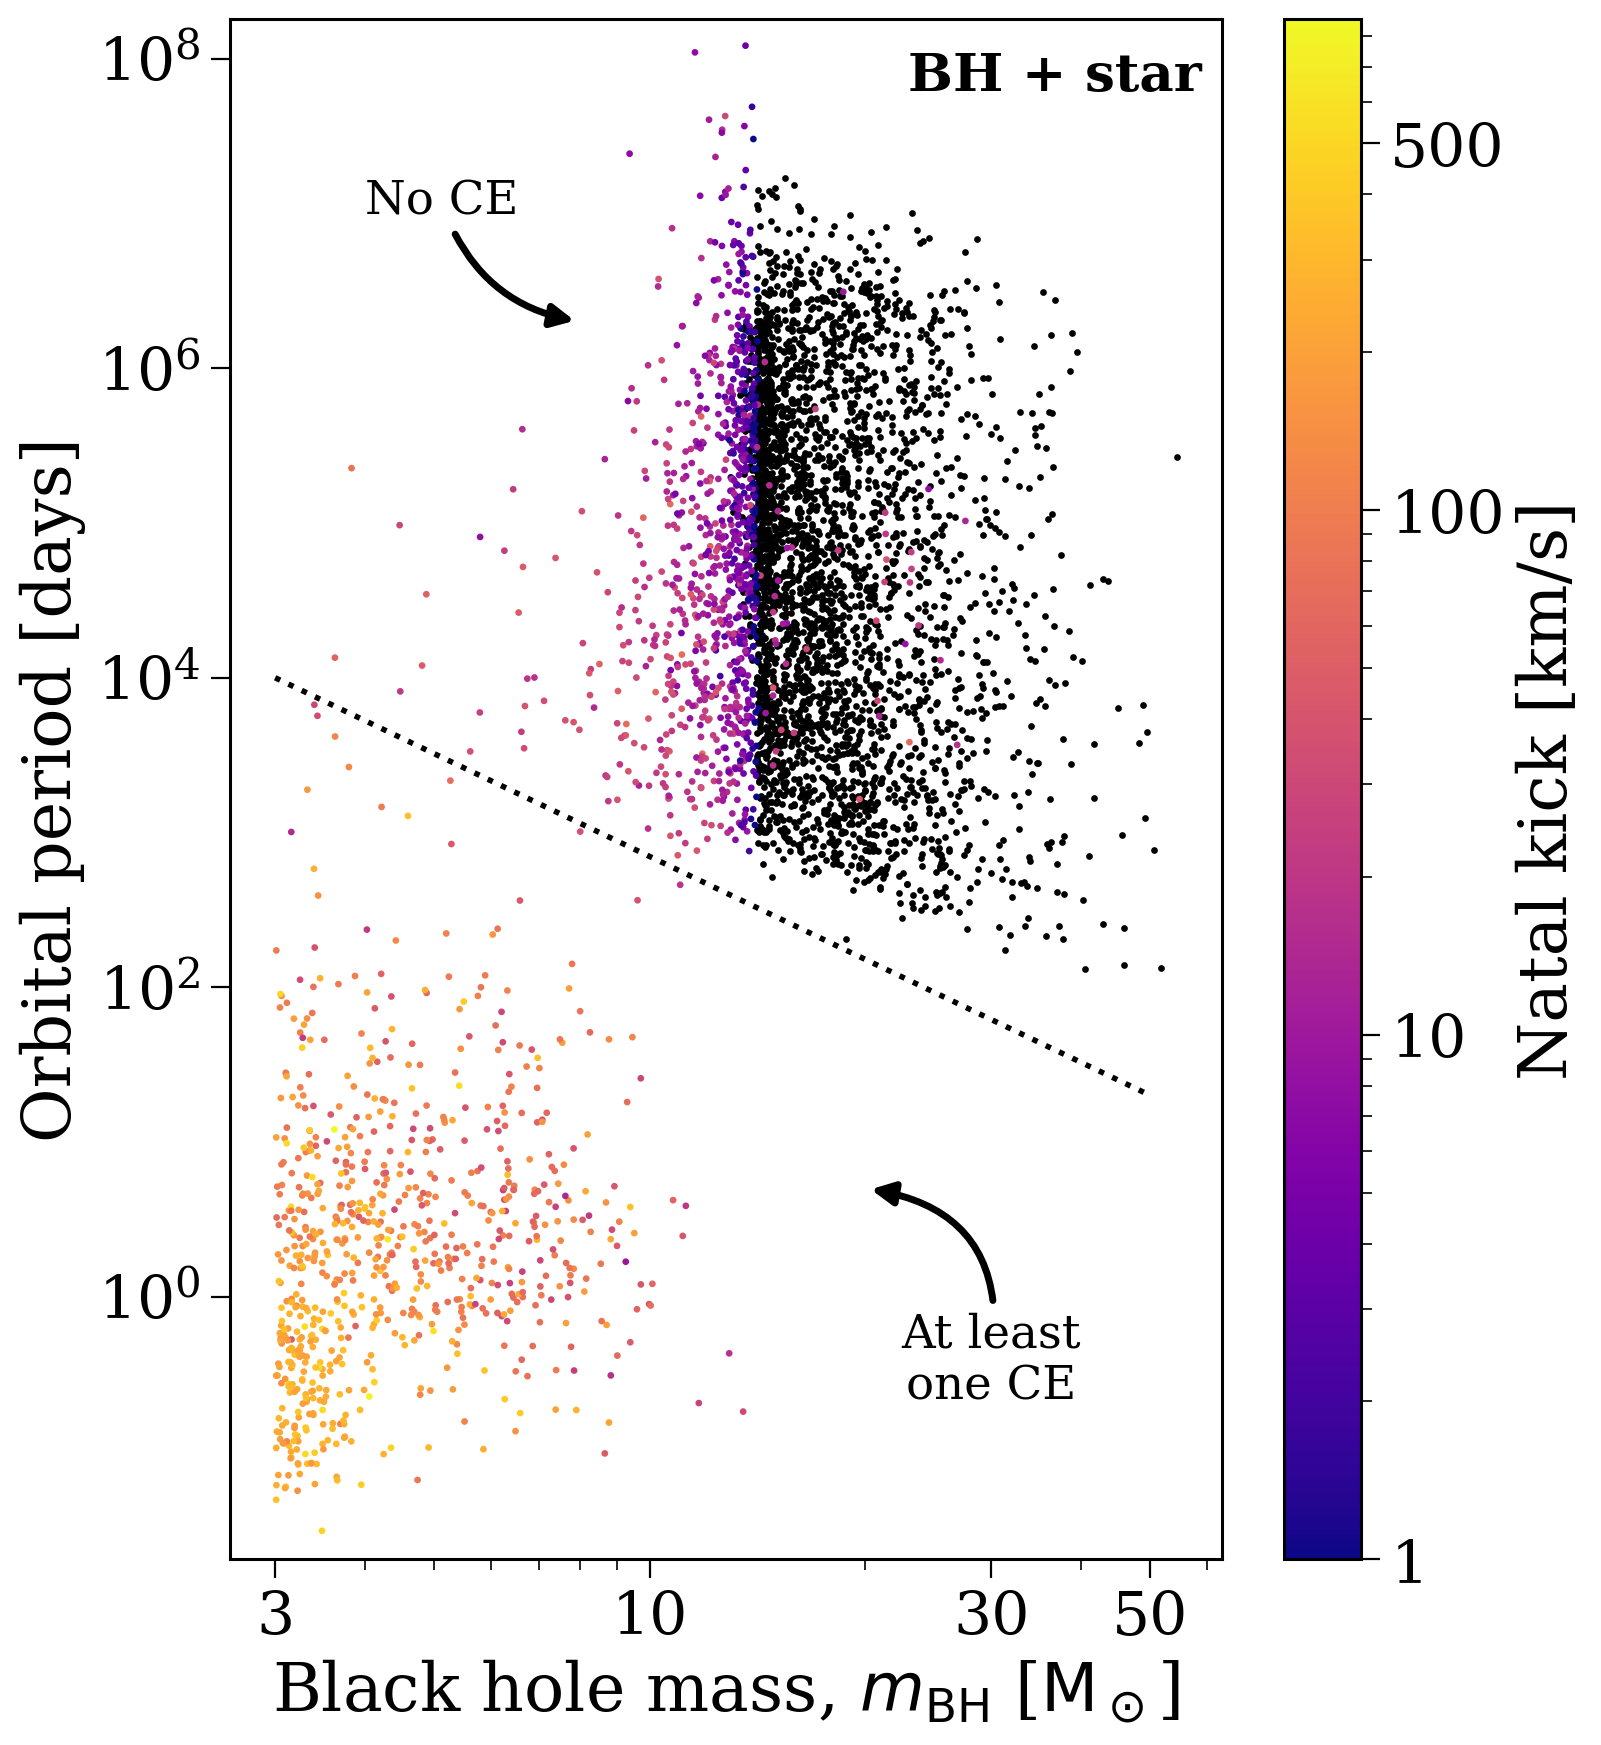

In [338]:
fig, ax = plt.subplots(figsize=(8, 10))

# had_ce = np.isin(bh_star_pop.bin_nums, bh_star_pop.bpp[bh_star_pop.bpp["evol_type"] == 3]["bin_num"])
# plt.scatter(bh_star_pop.final_bpp["mass_1"], bh_star_pop.final_bpp["porb"], c=had_ce, s=5)

kick_strength = bh_star_pop.kick_info[bh_star_pop.kick_info["star"] == 1]["natal_kick"]
got_kicked = kick_strength > 0
ax.scatter(bh_star_pop.final_bpp["mass_1"][~got_kicked], bh_star_pop.final_bpp["porb"][~got_kicked], c='k', s=2)
scatter = ax.scatter(bh_star_pop.final_bpp["mass_1"][got_kicked], bh_star_pop.final_bpp["porb"][got_kicked], c=kick_strength[got_kicked], s=2, norm=mpl.colors.LogNorm(vmin=1), cmap="plasma")

# inset_ax = ax.inset_axes([0.05, 0.85, 0.6, 0.1])

cbar = fig.colorbar(scatter, label="Natal kick [km/s]", format="%.0f")
cbar.set_ticks([1, 10, 100, 500], labels=[1, 10, 100, 500])

ax.set(
    xlabel=r"Black hole mass, $m_{\mathrm{BH}}$ [$\rm M_\odot$]",
    ylabel="Orbital period [days]",
    xscale='log',
    yscale="log",
    ylim=(2e-2, 1.8e8)
)

# ax.xaxis.set_minor_locator(plt.MultipleLocator(1))
ax.xaxis.set_major_locator(plt.MultipleLocator(10))
ax.set_xticks([3, 10, 30, 50], labels=[3, 10, 30, 50])

# add an annotation in the lower right corner with an arc arrow that points diagonally up left
ax.annotate("At least\none CE", xy=(20, 5), xytext=(30, 0.8), arrowprops=dict(arrowstyle="-|>", color='k', lw=2.5, connectionstyle="arc3,rad=0.5"), fontsize=0.7*fs, ha='center', va='top')
ax.annotate("No CE", xy=(8, 2e6), xytext=(4, 1e7), arrowprops=dict(arrowstyle="-|>", color='k', lw=2.5, connectionstyle="arc3,rad=0.3"), fontsize=0.7*fs)

# diagonal dashed line
ax.plot([3, 50], [1e4, 2e1], ls=':', c='k', lw=2, zorder=-1)

ax.annotate("BH + star", xy=(0.98, 0.98), xycoords='axes fraction', ha='right', va='top',
            fontsize=0.8*fs, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none"), fontweight='bold')

plt.savefig("../plots/bh_star_mbh_vs_porb.pdf", bbox_inches='tight', format='pdf')
plt.show()

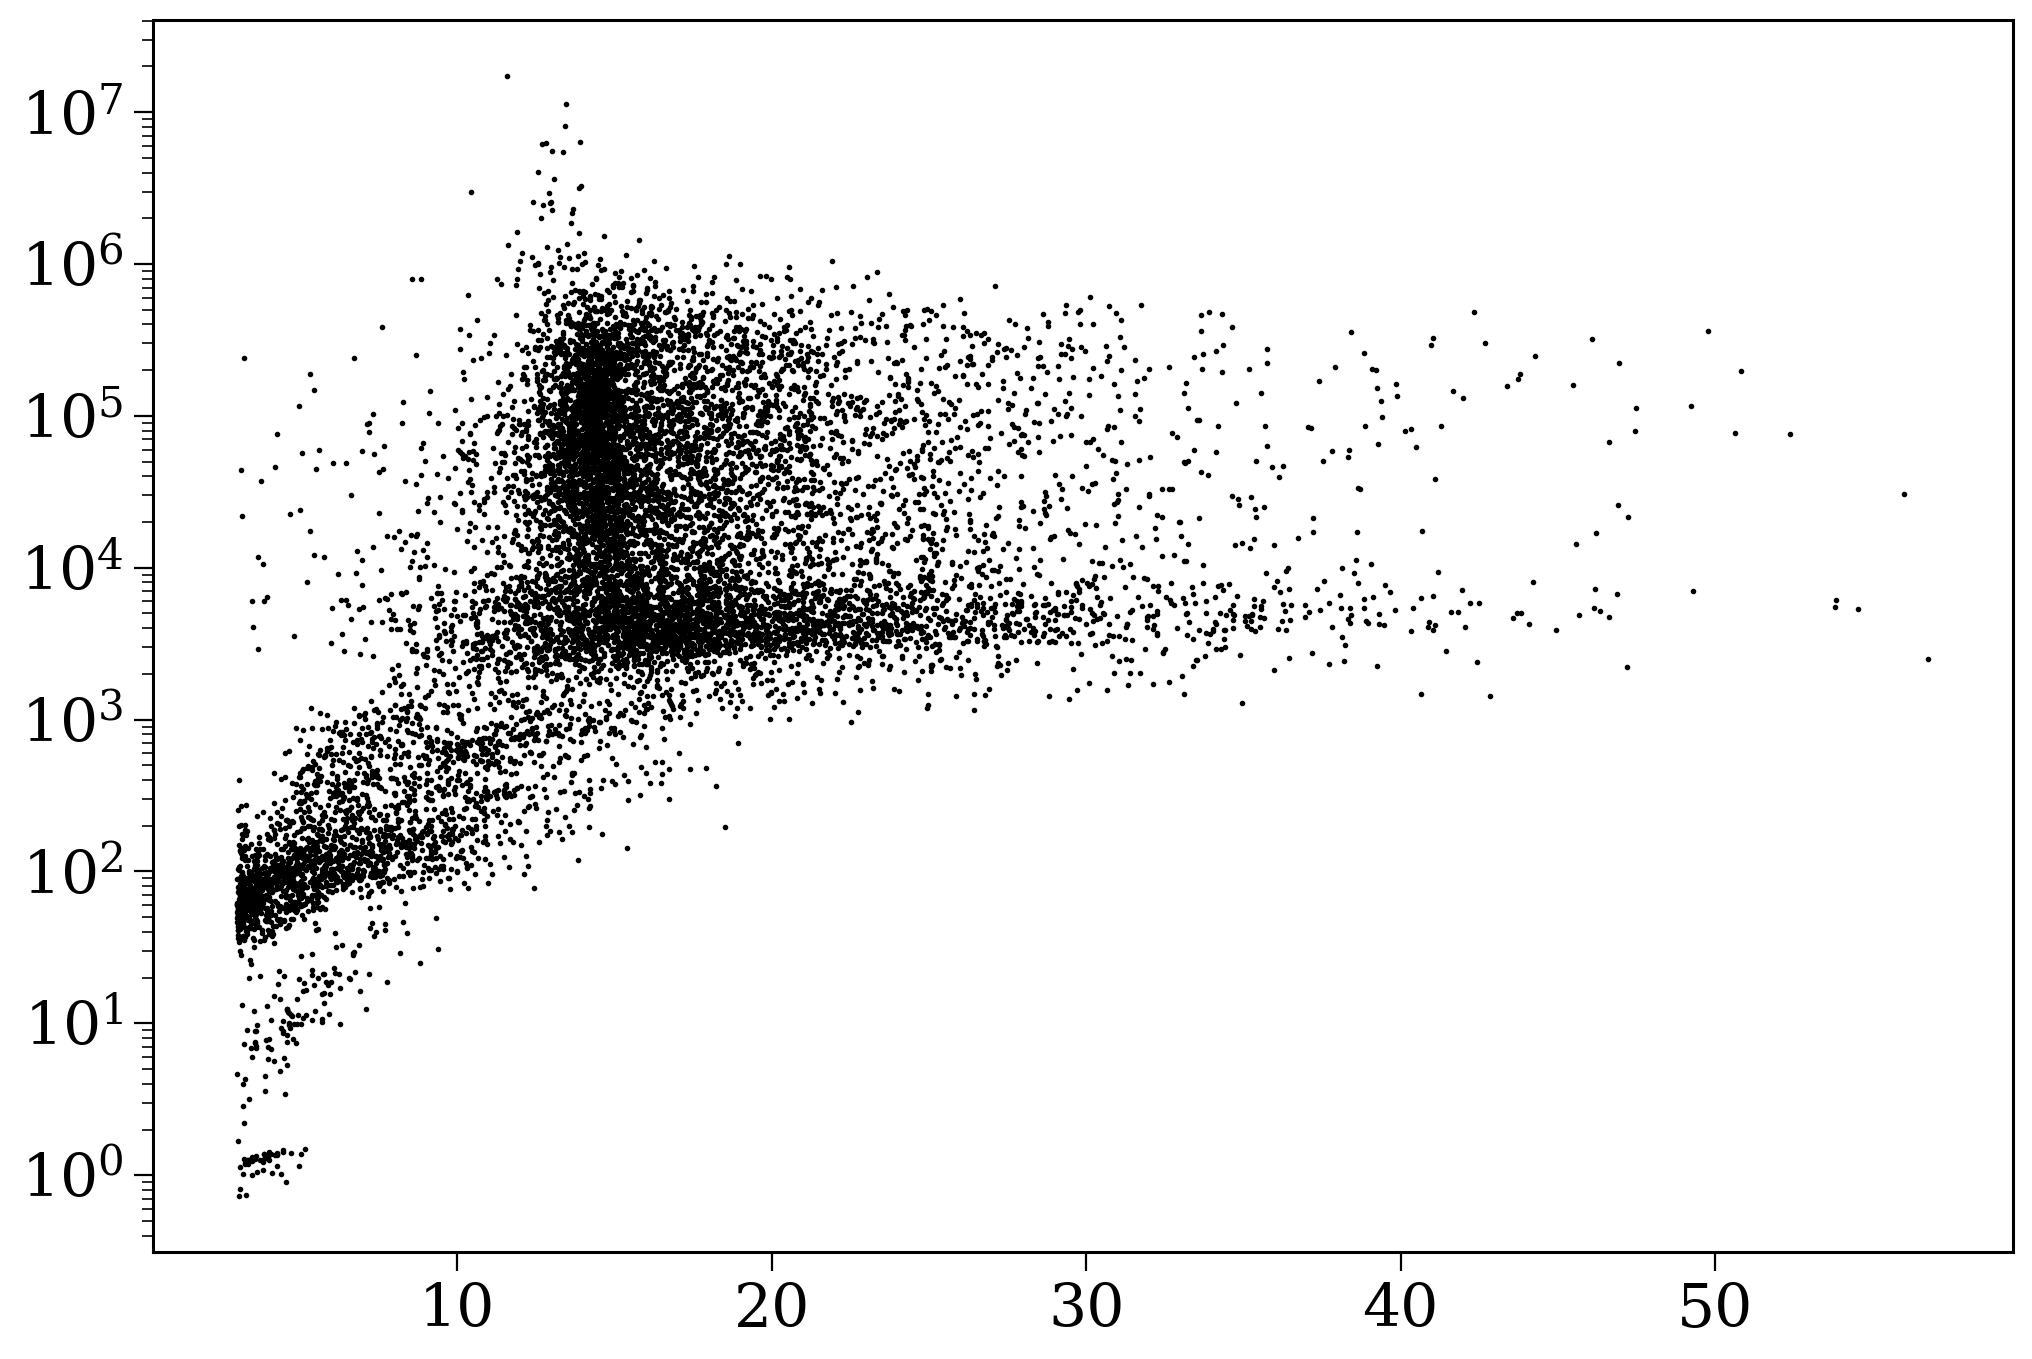

In [119]:
bound = data["Fiducial"]["sep"]["BH"] > 0
bh_wd = bound & (data["Fiducial"]["companion"]["BH"] >= 10) & (data["Fiducial"]["companion"]["BH"] <= 12)
plt.scatter(data["Fiducial"]["mass"]["BH"][bh_wd], data["Fiducial"]["sep"]["BH"][bh_wd], c='k', s=1)
plt.yscale("log")

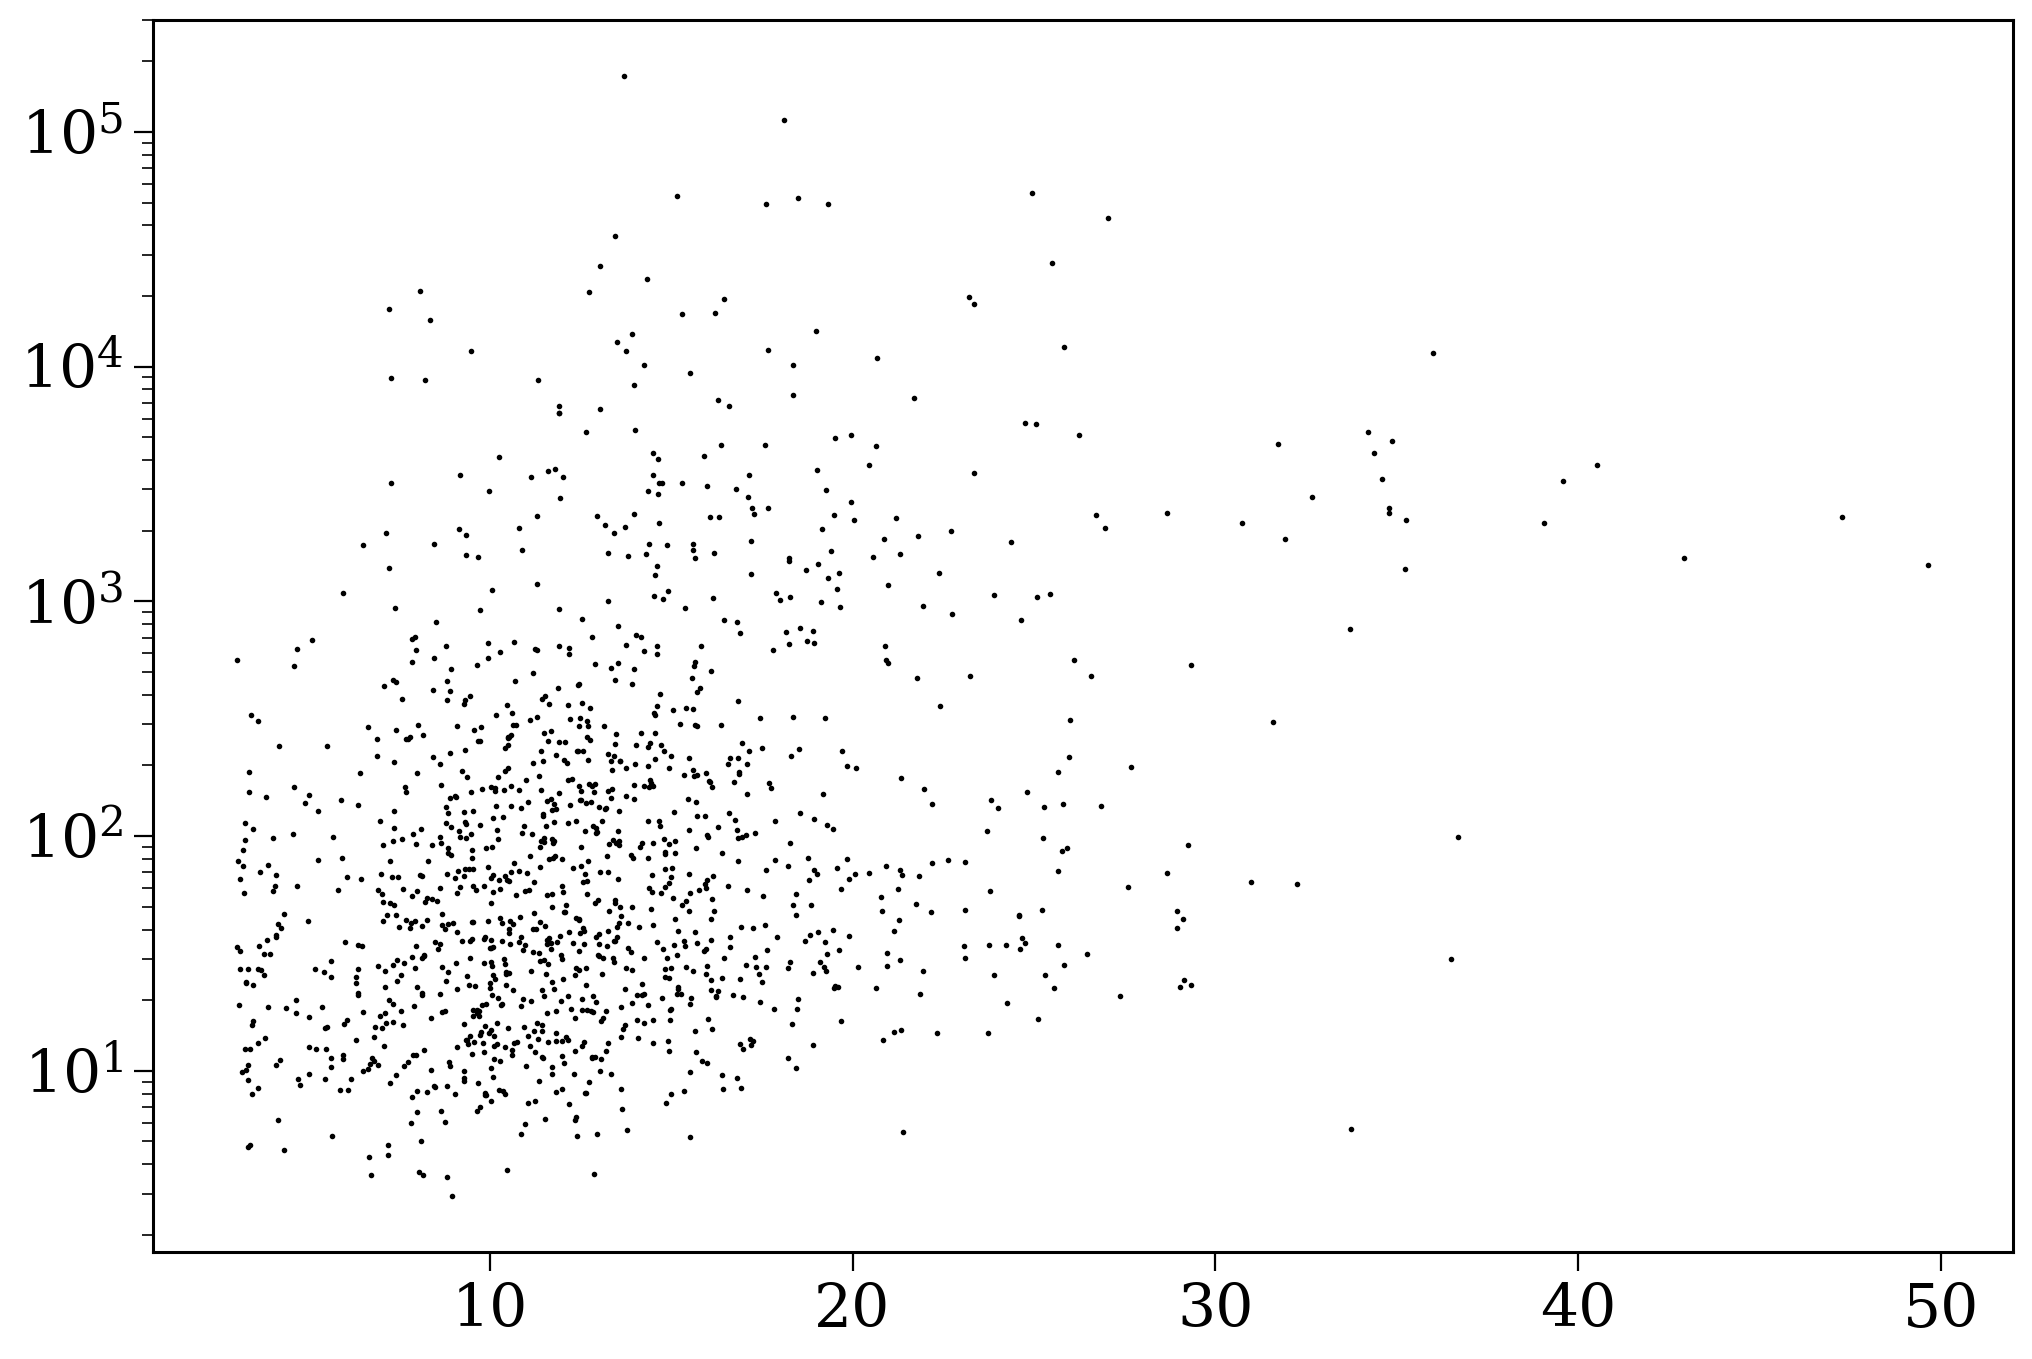

In [127]:
bound = data["Fiducial"]["sep"]["BH"] > 0
bh_ns = bound & (data["Fiducial"]["companion"]["BH"] == 13)
plt.scatter(data["Fiducial"]["mass"]["BH"][bh_ns], data["Fiducial"]["sep"]["BH"][bh_ns], c='k', s=1)
plt.yscale("log")

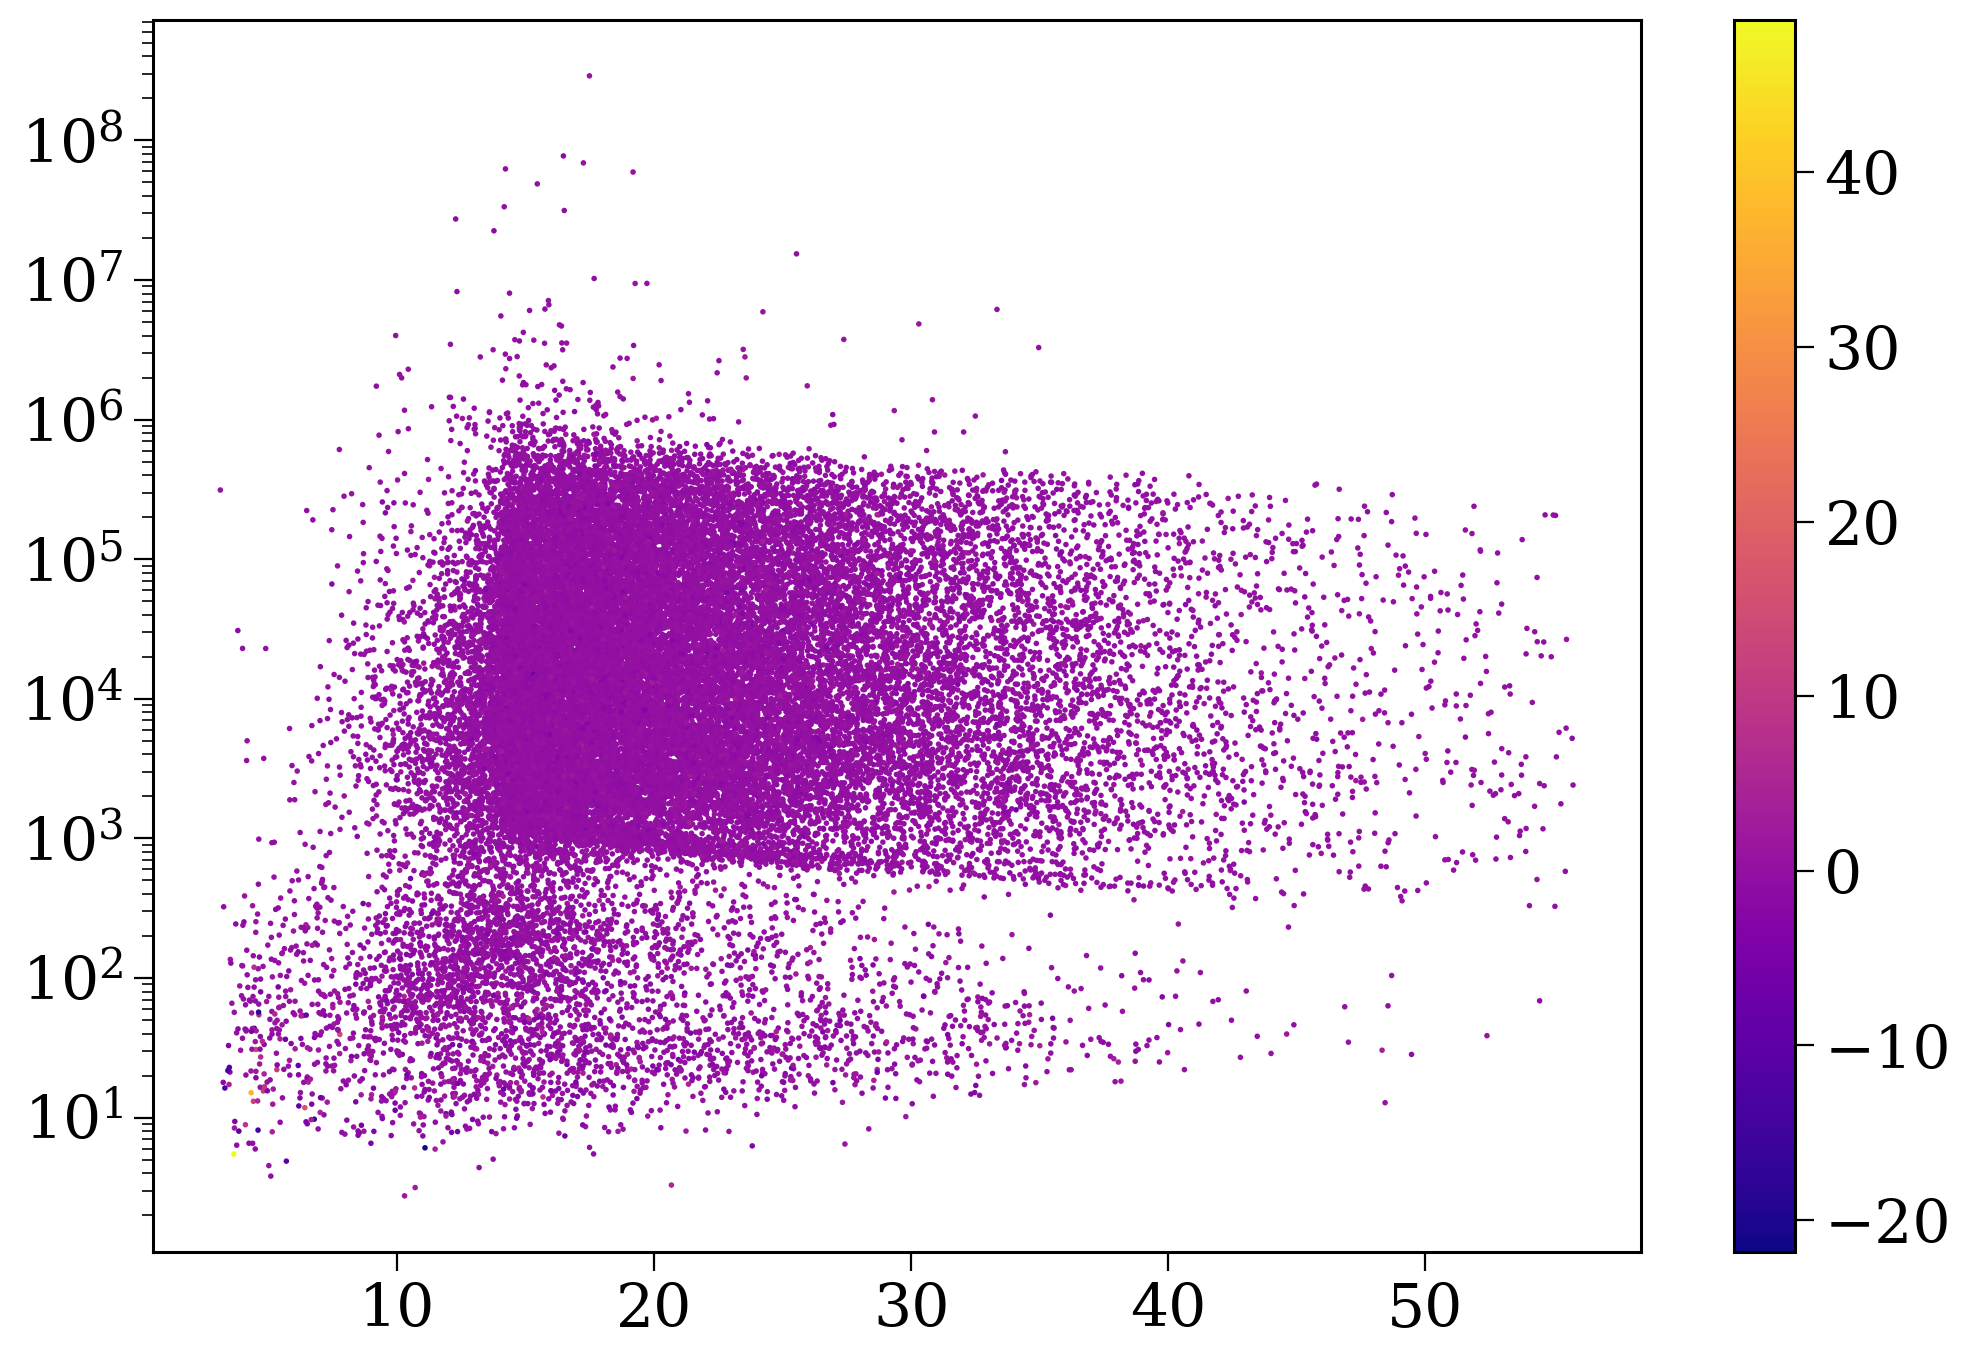

In [131]:
bound = data["Fiducial"]["sep"]["BH"] > 0
bh_bh = bound & (data["Fiducial"]["companion"]["BH"] == 14) & (data["Fiducial"]["primary"]["BH"])
scatter = plt.scatter(data["Fiducial"]["mass"]["BH"][bh_bh], data["Fiducial"]["sep"]["BH"][bh_bh], s=1, c=data["Fiducial"]["pos"]["BH"][bh_bh][:, 2], cmap="plasma")
plt.colorbar(scatter)
plt.yscale("log")

In [190]:
test = cogsworth.pop.load("/mnt/ceph/users/twagg/underworld/fiducial_m2min/fiducial_m2min_part0.h5")
test.initial_binaries["metallicity"].describe()

/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/site-packages/cogsworth/pop.py:2005: FutureWarning: cogsworth warning: m1_cutoff will be deprecated in v3.8+ of cogsworth. This can be achieved by just masking the initial binary table after sampling.
  p = Population(


count    177536.000000
mean          0.009723
std           0.007979
min           0.000100
25%           0.003662
50%           0.007117
75%           0.013627
max           0.030000
Name: metallicity, dtype: float64

In [374]:
np.linspace(3, 50,60)

array([ 3.        ,  3.79661017,  4.59322034,  5.38983051,  6.18644068,
        6.98305085,  7.77966102,  8.57627119,  9.37288136, 10.16949153,
       10.96610169, 11.76271186, 12.55932203, 13.3559322 , 14.15254237,
       14.94915254, 15.74576271, 16.54237288, 17.33898305, 18.13559322,
       18.93220339, 19.72881356, 20.52542373, 21.3220339 , 22.11864407,
       22.91525424, 23.71186441, 24.50847458, 25.30508475, 26.10169492,
       26.89830508, 27.69491525, 28.49152542, 29.28813559, 30.08474576,
       30.88135593, 31.6779661 , 32.47457627, 33.27118644, 34.06779661,
       34.86440678, 35.66101695, 36.45762712, 37.25423729, 38.05084746,
       38.84745763, 39.6440678 , 40.44067797, 41.23728814, 42.03389831,
       42.83050847, 43.62711864, 44.42372881, 45.22033898, 46.01694915,
       46.81355932, 47.61016949, 48.40677966, 49.20338983, 50.        ])

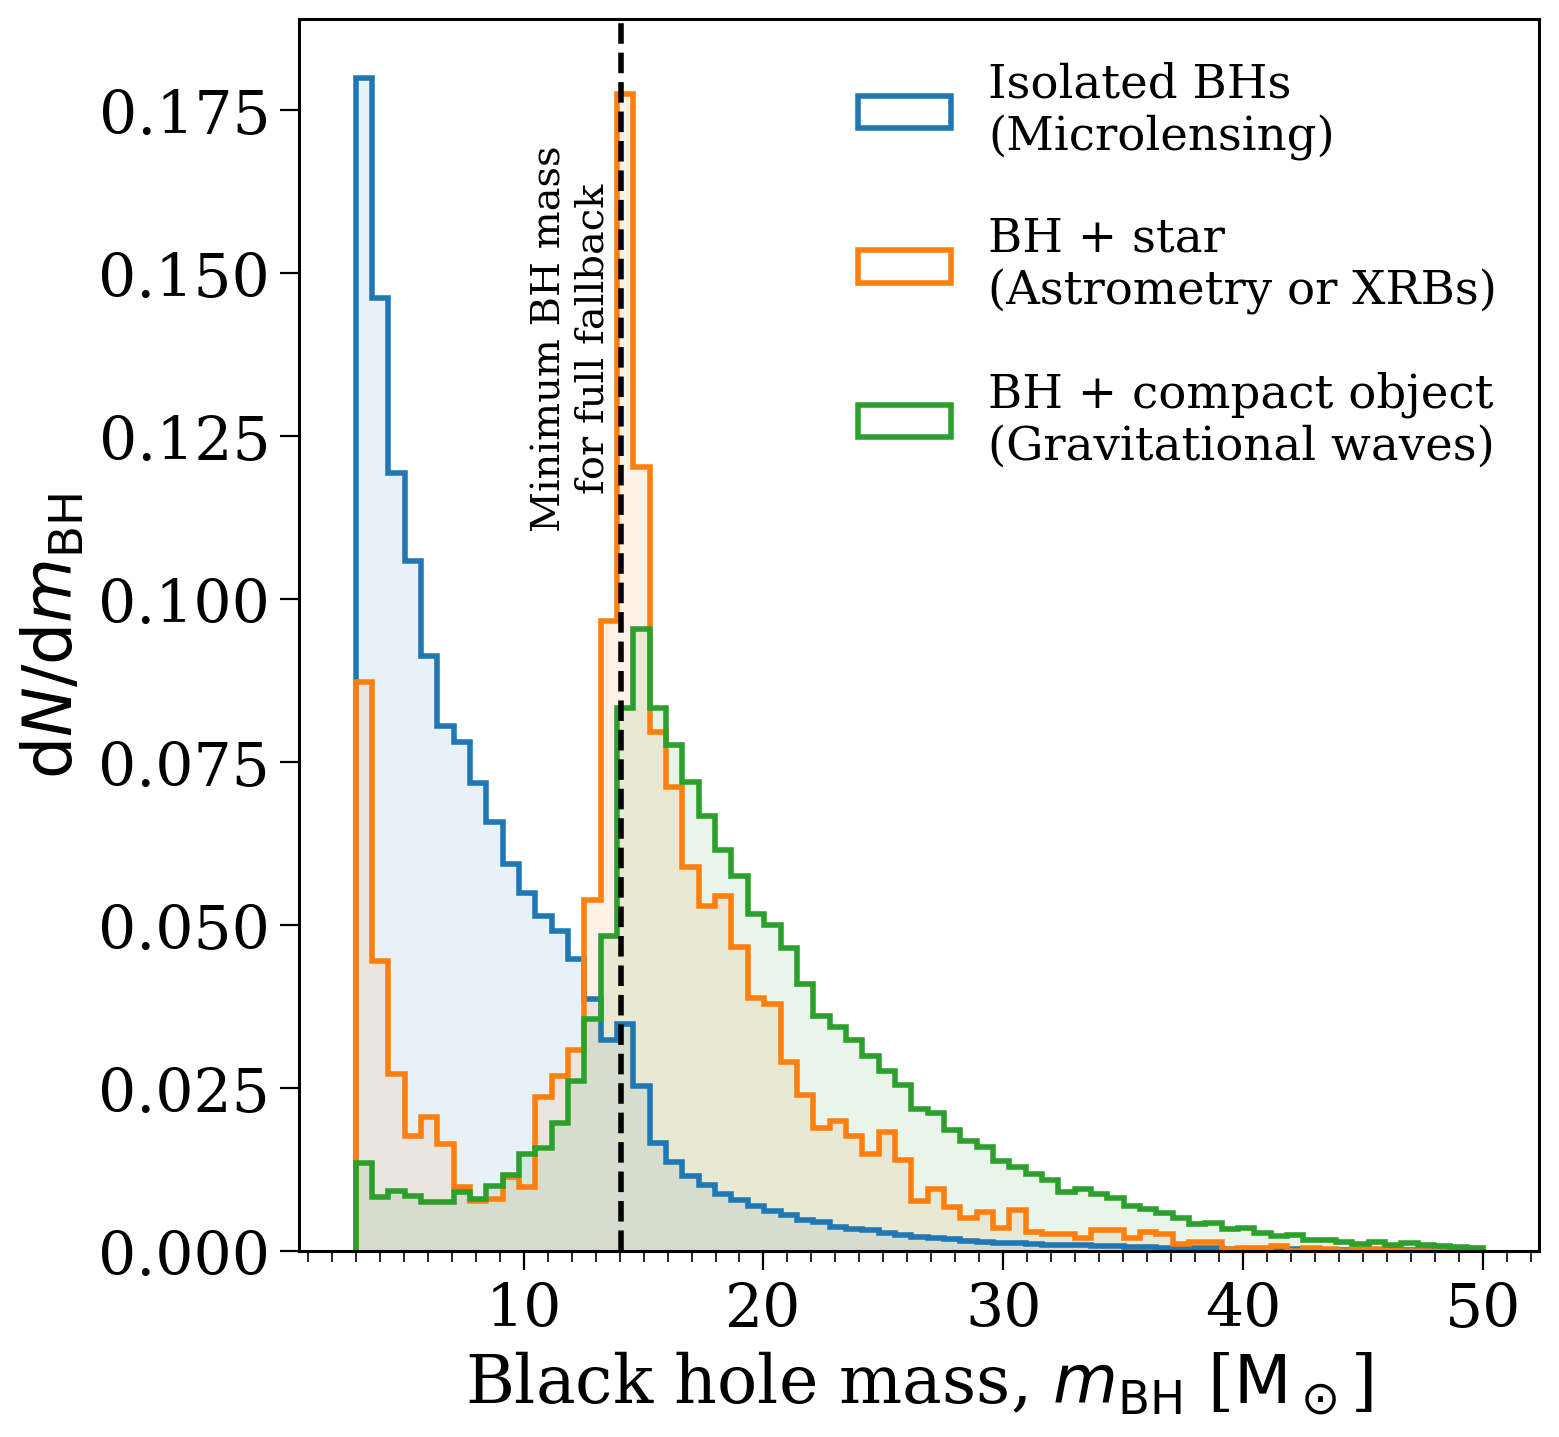

In [379]:
fig, ax = plt.subplots(figsize=(8, 8))

bins = np.linspace(3, 50, 70)
density = True
colours = ['tab:blue', 'tab:orange', 'tab:green']

for masses, colour, label in zip(
    [
        data["Fiducial"]["mass"]["BH"][data["Fiducial"]["sep"]["BH"] <= 0],
        bh_star_pop.final_bpp["mass_1"],
        data["Fiducial"]["mass"]["BH"][bh_bh | bh_ns | bh_wd],
    ],
    colours,
    ["Isolated BHs\n(Microlensing)","BH + star\n(Astrometry or XRBs)", "BH + compact object\n(Gravitational waves)"]
):
    plotting.nice_transparent_hist(
        ax, data=masses, bins=bins, colour=colour, alpha=0.1, label=label, density=density, lw=2
    )


ax.axvline(14.04, ls='--', c='k', lw=2)

ax.annotate("Minimum BH mass\nfor full fallback", xy=(12, 0.14), fontsize=0.6*fs, ha='center', va='center', rotation=90)

ax.xaxis.set_major_locator(plt.MultipleLocator(10))
ax.xaxis.set_minor_locator(plt.MultipleLocator(1))

leg = ax.legend(fontsize=0.7*fs, frameon=False, loc='upper right', labelspacing=1.2)

ax.set(
    xlabel=r"Black hole mass, $m_{\mathrm{BH}}$ [$\rm M_\odot$]",
    ylabel=r"${\rm d}N/{\rm d}m_{\mathrm{BH}}$",
)

plt.savefig("../plots/bh_binary_masses.pdf", bbox_inches='tight', format='pdf')
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


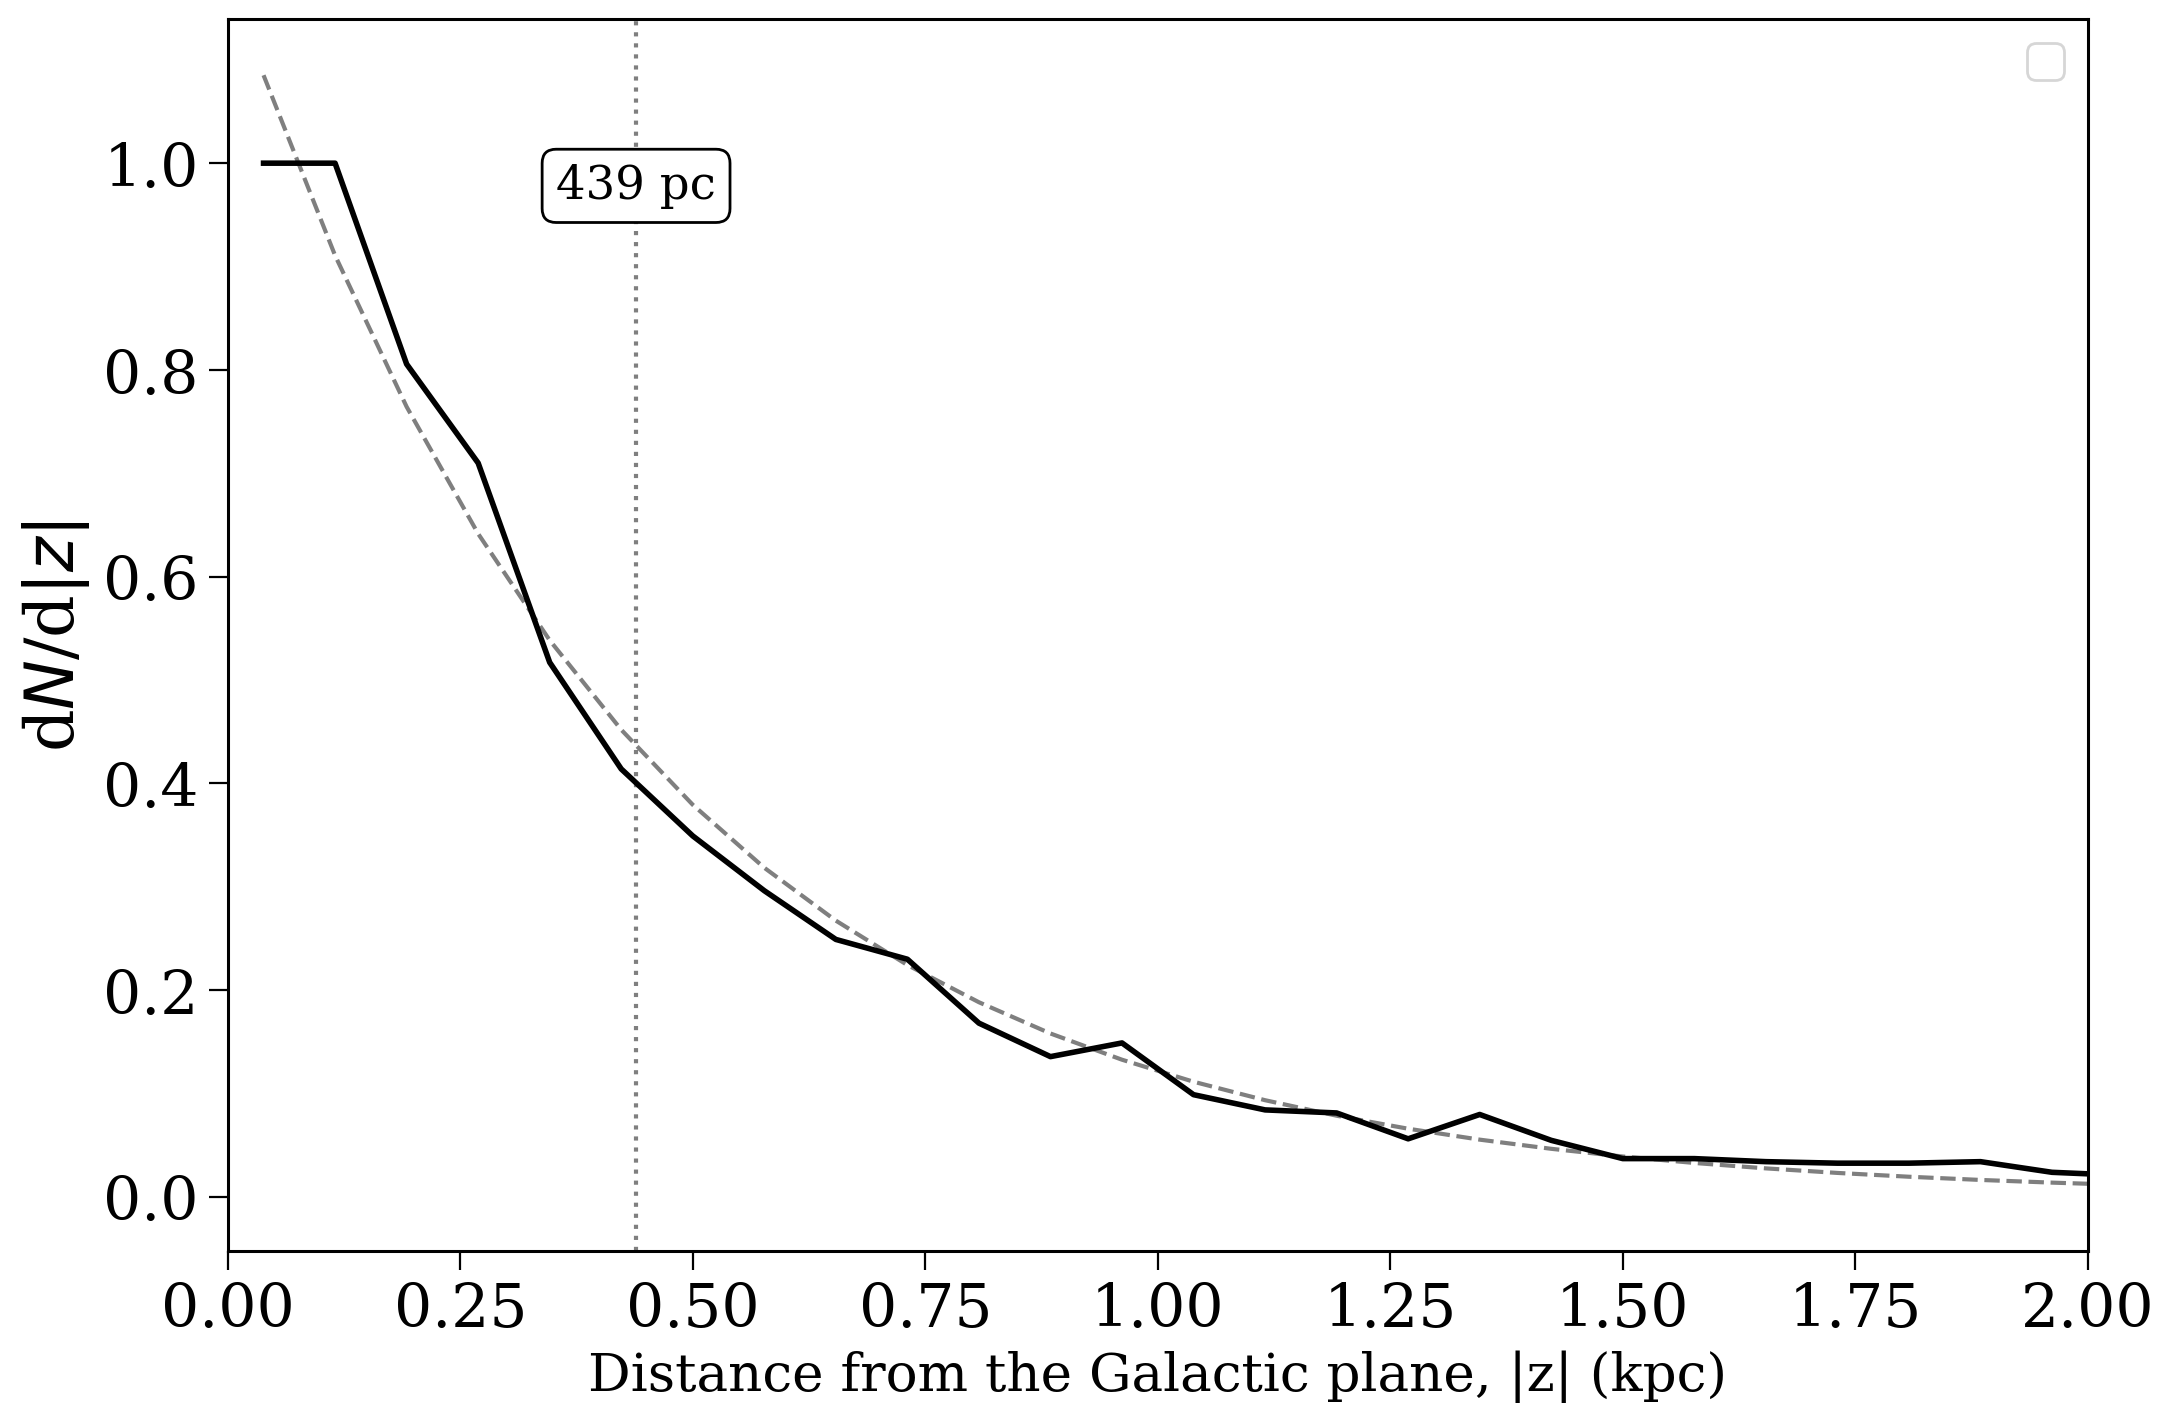

(np.float64(0.4390287805756115),
 np.float64(0.05837619745739041),
 <Figure size 1200x800 with 1 Axes>,
 <Axes: xlabel='Distance from the Galactic plane, |z| (kpc)', ylabel='d$N$/d$|z|$'>)

In [133]:
plotting.estimate_scale_height(
    bh_star_pop.final_pos[:, 2].value,
    bins=np.linspace(0, 3, 40),
    xlim=(0, 2),
    plot=True
)

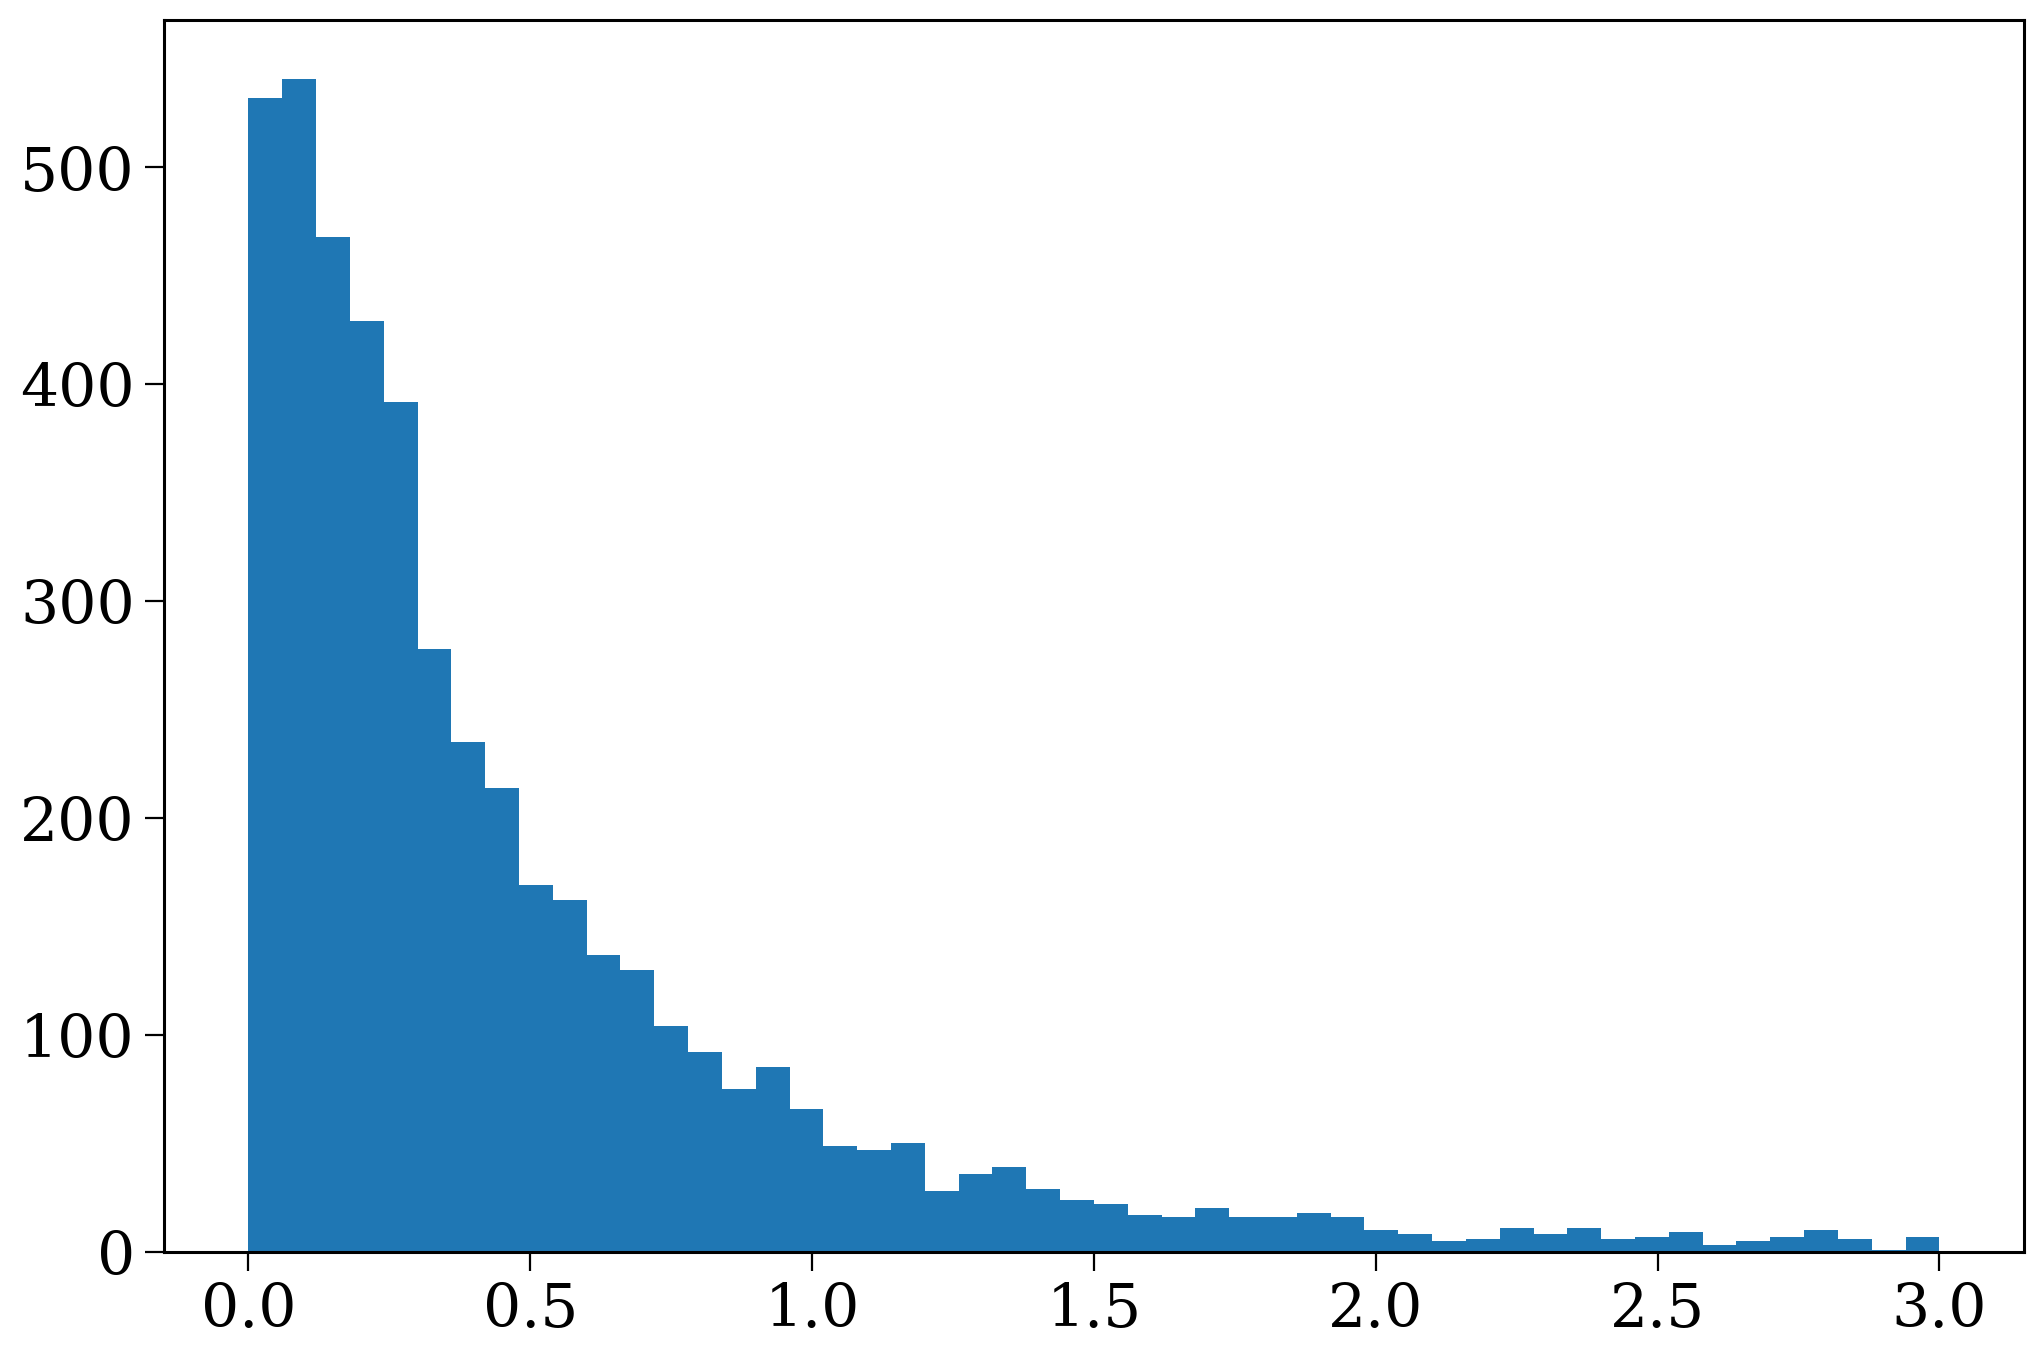

In [128]:
plt.hist(abs(bh_star_pop.final_pos[:, 2].value), bins="auto", range=(0, 3));

(array([143.,  99.,  74.,  83.,  87., 103., 111., 108., 115., 118., 136.,
        152., 166., 211., 227., 258., 342., 358., 418., 426., 446., 444.,
        284.]),
 array([4.70047284e-03, 5.20627702e-01, 1.03655493e+00, 1.55248216e+00,
        2.06840939e+00, 2.58433662e+00, 3.10026385e+00, 3.61619108e+00,
        4.13211831e+00, 4.64804554e+00, 5.16397277e+00, 5.67990000e+00,
        6.19582723e+00, 6.71175446e+00, 7.22768169e+00, 7.74360892e+00,
        8.25953615e+00, 8.77546338e+00, 9.29139060e+00, 9.80731783e+00,
        1.03232451e+01, 1.08391723e+01, 1.13550995e+01, 1.18710268e+01]),
 <BarContainer object of 23 artists>)

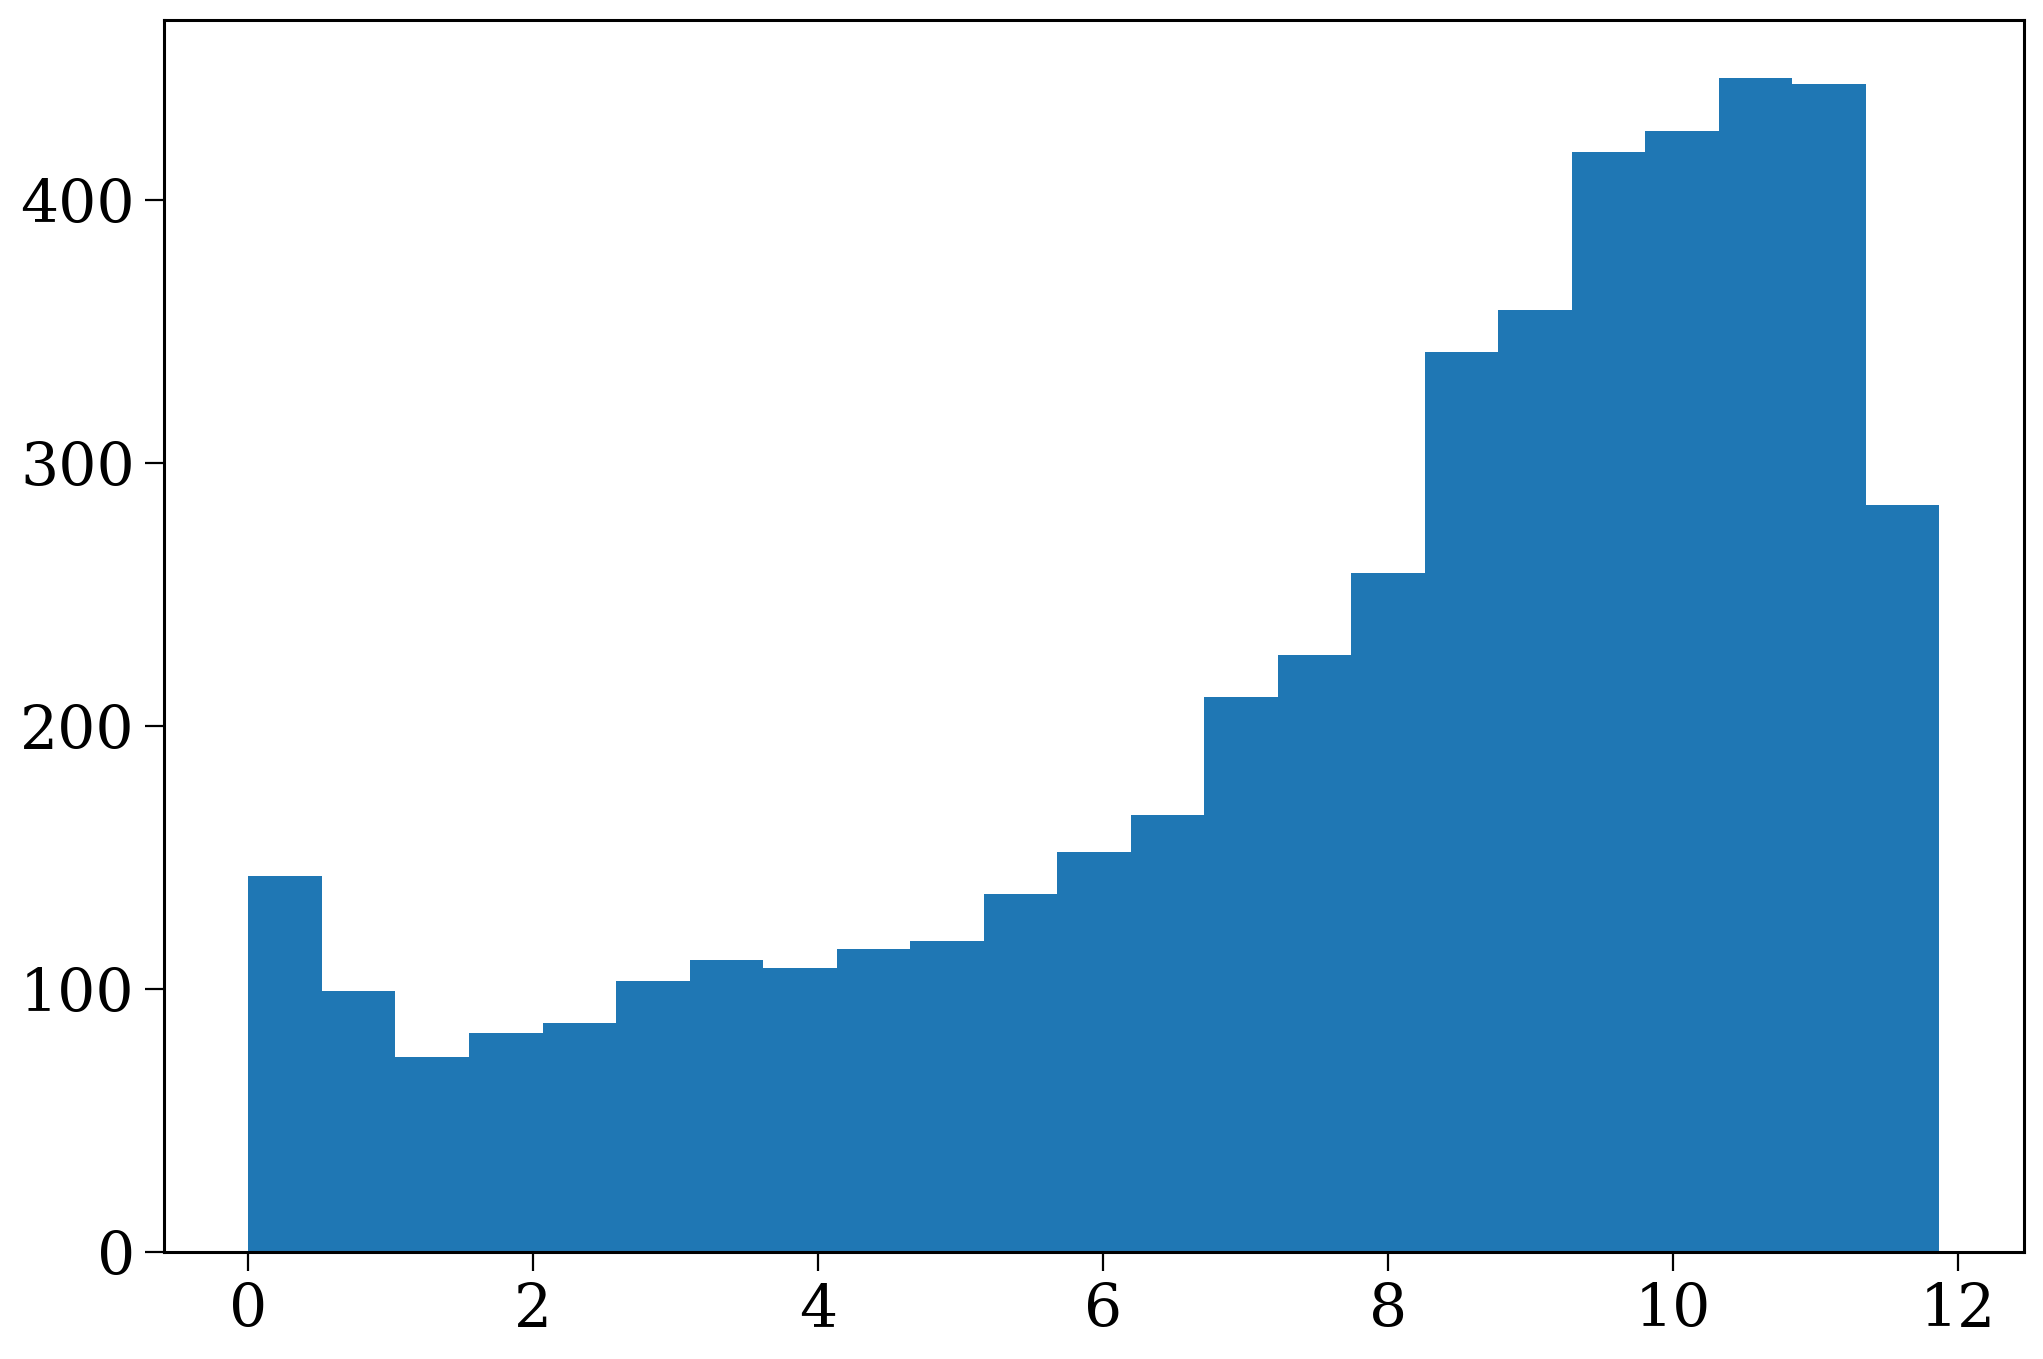

In [130]:
plt.hist(bh_star_pop.initial_galaxy.tau, bins="auto")